# E-Commerce Returns Fraud vs Warehouse Efficiency
## MGT3014 — Operations Analytics | Review 2

**Team:** 22MIA1067 · 22MIA1084 · 22MIA1165 · 22MIA1174 · 22MIA1197  
**Guide:** Dr. Balaji J, VIT Business School  

---

### Datasets Used
| Dataset | Source | Records | Purpose |
|---|---|---|---|
| `final_return_dataset.csv` | Brazilian Olist (Kaggle) | 1,11,702 | EDA & real-world context |
| `QuickCommerce_ReturnFraud_Dataset.xlsx` | Primary (Simulated QC) | 250 | ML Modelling |
| `Consumer_Survey.xlsx` | Primary Survey | 80 | Contextual insights |

### Notebook Structure
1. Setup & Data Loading  
2. Exploratory Data Analysis (EDA)  
3. Data Leakage Analysis  
4. Preprocessing & Synthetic Data (SMOTE)  
5. Model Training & Comparison  
6. Results, Evaluation & Insights

---
## 1. Setup & Data Loading

In [ ]:
# Install dependencies (run once in Colab)
# !pip install imbalanced-learn xgboost --quiet

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import xgboost as xgb

# Plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 13

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [2]:
# ── Load all three datasets ─────────────────────────────────────

# Dataset 1: Olist (real-world Brazilian e-commerce, Kaggle)
df_olist = pd.read_csv("/content/final_return_dataset.csv")

# Dataset 2: QuickCommerce (primary simulated dataset — Blinkit / Swiggy Instamart)
df_qc = pd.read_excel("/content/QuickCommerce_ReturnFraud_Dataset.xlsx")

# Dataset 3: Consumer Survey (primary, N=80)
df_survey = pd.read_excel(
    "/content/Consumer Behavior and Product Return Practices in E-Commerce (Responses).xlsx"
)

print(f"Olist dataset:      {df_olist.shape[0]:>7,} rows × {df_olist.shape[1]} cols")
print(f"QuickCommerce:      {df_qc.shape[0]:>7,} rows × {df_qc.shape[1]} cols")
print(f"Consumer Survey:    {df_survey.shape[0]:>7,} rows × {df_survey.shape[1]} cols")

Olist dataset:      111,702 rows × 6 cols
QuickCommerce:          250 rows × 14 cols
Consumer Survey:         80 rows × 16 cols


In [3]:
# ── Basic column inspection ─────────────────────────────────────
print("=== Olist Columns ===")
print(df_olist.columns.tolist())

print("\n=== QuickCommerce Columns ===")
print(df_qc.columns.tolist())

=== Olist Columns ===
['product_category_name', 'return_reason', 'processing_category', 'inspection_level', 'warehouse_load', 'return_type']

=== QuickCommerce Columns ===
['Order_ID', 'Platform', 'Product_Category', 'Return_Reason', 'Return_Type', 'Inspection_Level', 'Warehouse_Load', 'Processing_Time_min', 'Return_Outcome', 'Refund_Amount_INR', 'Customer_Order_Frequency', 'Customer_Return_Frequency', 'Inspector_Required', 'Fraud_Risk_Score']


---
## 2. Exploratory Data Analysis (EDA)
### 2.1 Olist Dataset — Real-World E-Commerce Returns (N=1,11,702)

In [4]:
# ── Olist overview ──────────────────────────────────────────────
print("Shape:", df_olist.shape)
print("\nMissing values:")
print(df_olist.isnull().sum())
df_olist.head()

Shape: (111702, 6)

Missing values:
product_category_name    0
return_reason            0
processing_category      0
inspection_level         0
warehouse_load           0
return_type              0
dtype: int64


,product_category_name,return_reason,processing_category,inspection_level,warehouse_load,return_type
0,utilidades_domesticas,No Return,High,Intensive,High,Genuine
1,perfumaria,No Return,High,Intensive,Low,Genuine
2,automotivo,No Return,High,Intensive,High,Genuine
3,pet_shop,No Return,High,Intensive,High,Genuine
4,papelaria,No Return,Low,Basic,Low,Genuine


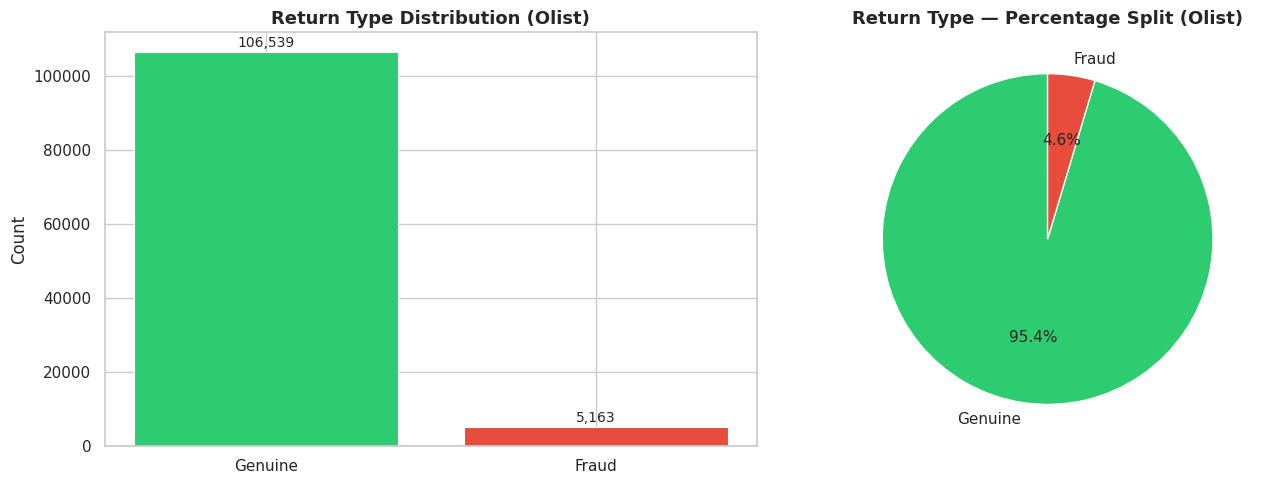


Class counts:
return_type
Genuine    106539
Fraud        5163
Name: count, dtype: int64

Fraud rate: 4.62%


In [5]:
# ── Olist: return_type distribution ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df_olist['return_type'].value_counts()
axes[0].bar(counts.index, counts.values,
            color=['#2ecc71','#e74c3c'], edgecolor='white', linewidth=0.8)
axes[0].set_title("Return Type Distribution (Olist)", fontweight='bold')
axes[0].set_ylabel("Count")
for bar, val in zip(axes[0].patches, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 500, f'{val:,}',
                 ha='center', va='bottom', fontsize=10)

pct = df_olist['return_type'].value_counts(normalize=True)*100
axes[1].pie(pct.values, labels=pct.index,
            autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'],
            startangle=90, textprops={'fontsize':11})
axes[1].set_title("Return Type — Percentage Split (Olist)", fontweight='bold')

plt.tight_layout()
plt.show()

print("\nClass counts:")
print(counts)
print(f"\nFraud rate: {pct['Fraud']:.2f}%")

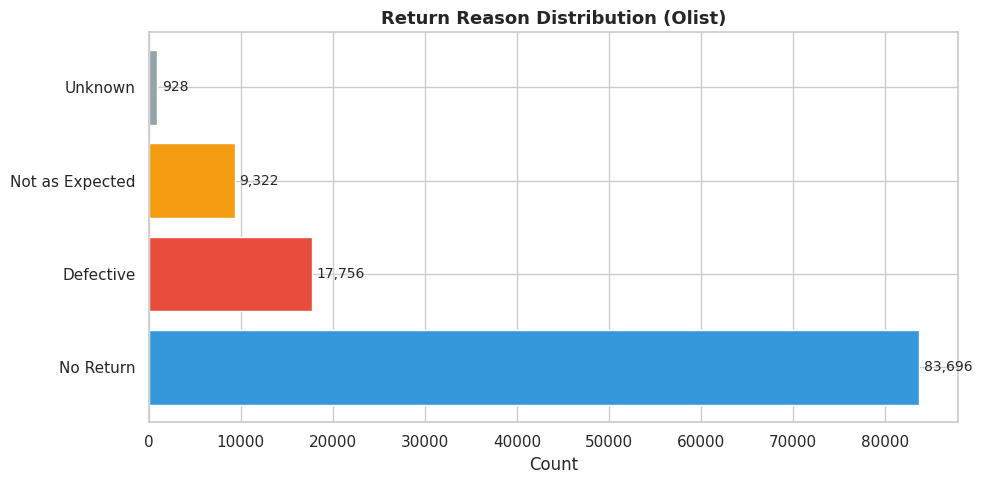


Key observation: 'No Return' (74.9%) = order completed normally.
'Defective' and 'Not as Expected' are the two main genuine return reasons.


In [6]:
# ── Olist: return reasons ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
rc = df_olist['return_reason'].value_counts()
bars = ax.barh(rc.index, rc.values,
               color=['#3498db','#e74c3c','#f39c12','#95a5a6'],
               edgecolor='white')
ax.set_title("Return Reason Distribution (Olist)", fontweight='bold')
ax.set_xlabel("Count")
for bar, val in zip(bars, rc.values):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

print("\nKey observation: 'No Return' (74.9%) = order completed normally.")
print("'Defective' and 'Not as Expected' are the two main genuine return reasons.")

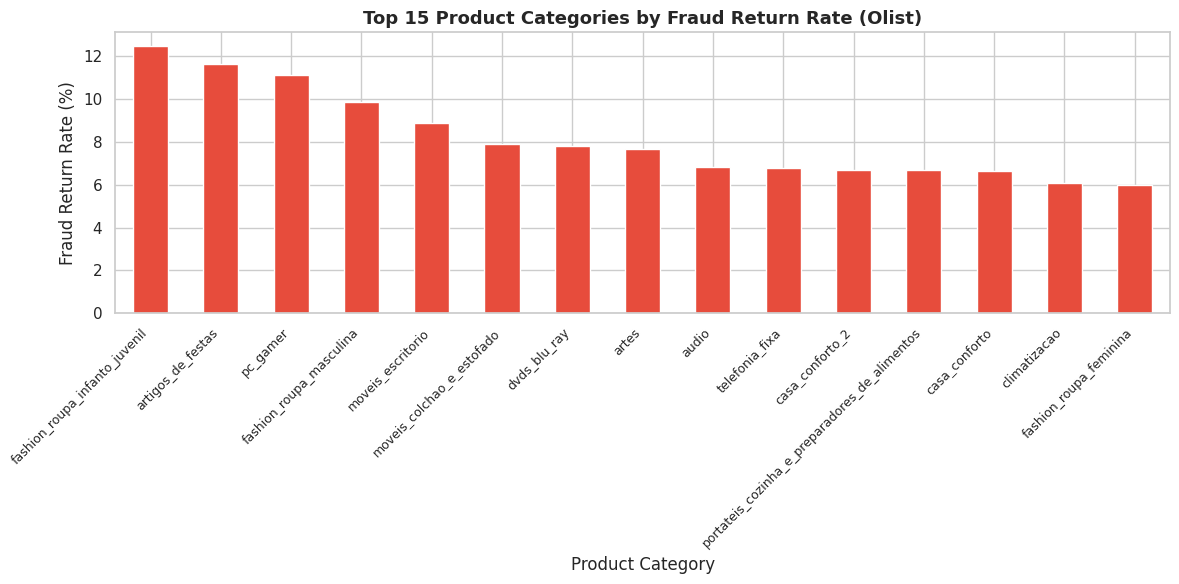

In [7]:
# ── Olist: Top 15 product categories by return rate ─────────────
cat_counts = df_olist.groupby(['product_category_name','return_type']).size().unstack(fill_value=0)
cat_counts['fraud_rate'] = cat_counts.get('Fraud', 0) / cat_counts.sum(axis=1) * 100
cat_counts = cat_counts.sort_values('fraud_rate', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
cat_counts['fraud_rate'].plot(kind='bar', color='#e74c3c', ax=ax, edgecolor='white')
ax.set_title("Top 15 Product Categories by Fraud Return Rate (Olist)", fontweight='bold')
ax.set_ylabel("Fraud Return Rate (%)")
ax.set_xlabel("Product Category")
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

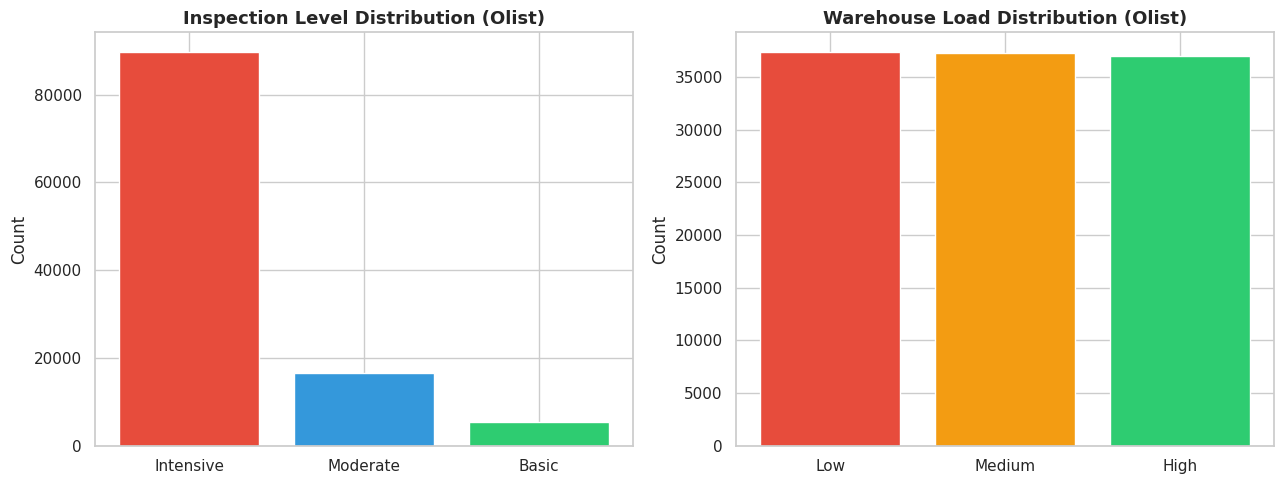

In [8]:
# ── Olist: Inspection level distribution ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

insp = df_olist['inspection_level'].value_counts()
axes[0].bar(insp.index, insp.values,
            color=['#e74c3c','#3498db','#2ecc71'], edgecolor='white')
axes[0].set_title("Inspection Level Distribution (Olist)", fontweight='bold')
axes[0].set_ylabel("Count")

wh = df_olist['warehouse_load'].value_counts()
axes[1].bar(wh.index, wh.values,
            color=['#e74c3c','#f39c12','#2ecc71'], edgecolor='white')
axes[1].set_title("Warehouse Load Distribution (Olist)", fontweight='bold')
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

### 2.2 QuickCommerce Dataset — Primary Modelling Data (N=250)

In [9]:
# ── QuickCommerce overview ──────────────────────────────────────
print("Shape:", df_qc.shape)
print("\nMissing values:")
print(df_qc.isnull().sum())
print()
df_qc.describe(include='all').T

Shape: (250, 14)

Missing values:
Order_ID                     0
Platform                     0
Product_Category             0
Return_Reason                0
Return_Type                  0
Inspection_Level             0
Warehouse_Load               0
Processing_Time_min          0
Return_Outcome               0
Refund_Amount_INR            0
Customer_Order_Frequency     0
Customer_Return_Frequency    0
Inspector_Required           0
Fraud_Risk_Score             0
dtype: int64



,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Order_ID,250,250,ORD00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Platform,250,2,Blinkit,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Category,250,8,Dairy,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Return_Reason,250,12,Wrong Item Delivered,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Return_Type,250,2,Genuine,165,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Inspection_Level,250,3,Basic,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Warehouse_Load,250,3,Medium,95,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Processing_Time_min,250.0,NaN,NaN,NaN,38.9046,34.156808,5.21,14.35,26.085,51.775,146.33
Return_Outcome,250,2,Accepted,162,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Refund_Amount_INR,250.0,NaN,NaN,NaN,462.07928,482.205671,25.41,205.285,362.105,509.385,2414.87


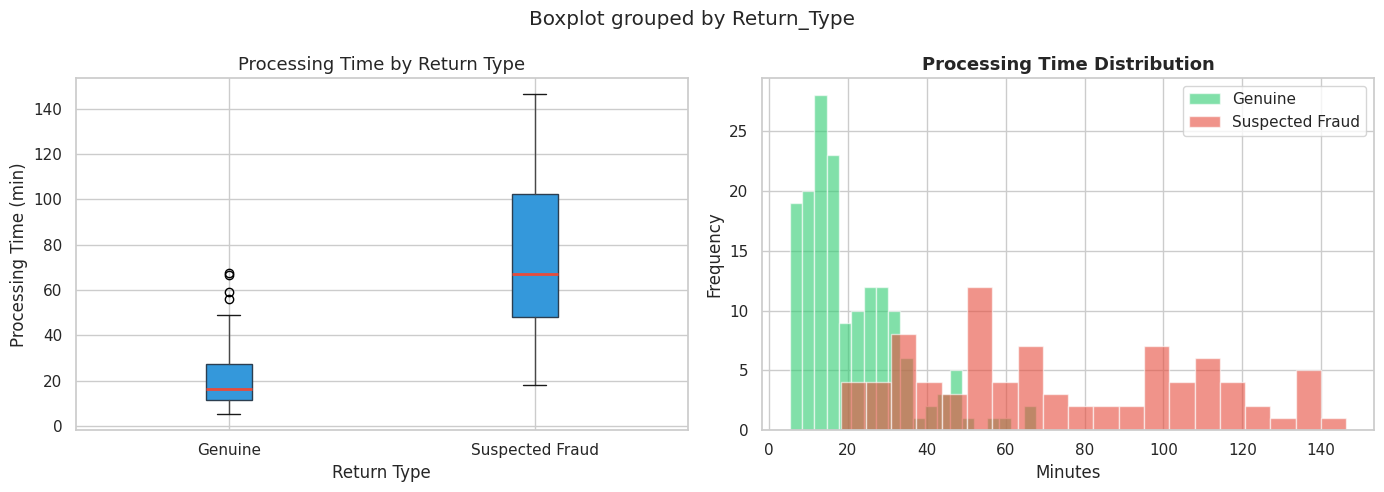

Mean processing time — Genuine:          20.74 min
Mean processing time — Suspected Fraud:  74.16 min
Ratio (Fraud/Genuine):                   3.58×


In [10]:
# ── Processing time: Genuine vs Suspected Fraud ─────────────────
genuine_pt  = df_qc[df_qc['Return_Type']=='Genuine']['Processing_Time_min']
fraud_pt    = df_qc[df_qc['Return_Type']=='Suspected Fraud']['Processing_Time_min']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
df_qc.boxplot(column='Processing_Time_min', by='Return_Type',
              ax=axes[0], patch_artist=True,
              boxprops=dict(facecolor='#3498db', color='#2c3e50'),
              medianprops=dict(color='#e74c3c', linewidth=2))
axes[0].set_title("Processing Time by Return Type", fontweight='bold')
axes[0].set_xlabel("Return Type")
axes[0].set_ylabel("Processing Time (min)")
plt.sca(axes[0])
plt.title("Processing Time by Return Type")

# Histogram
axes[1].hist(genuine_pt, bins=20, alpha=0.6, color='#2ecc71', label='Genuine')
axes[1].hist(fraud_pt,   bins=20, alpha=0.6, color='#e74c3c', label='Suspected Fraud')
axes[1].set_title("Processing Time Distribution", fontweight='bold')
axes[1].set_xlabel("Minutes")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Mean processing time — Genuine:          {genuine_pt.mean():.2f} min")
print(f"Mean processing time — Suspected Fraud:  {fraud_pt.mean():.2f} min")
print(f"Ratio (Fraud/Genuine):                   {fraud_pt.mean()/genuine_pt.mean():.2f}×")

In [11]:
# ── T-test: is the difference statistically significant? ────────
from scipy import stats

t_stat, p_val = stats.ttest_ind(genuine_pt, fraud_pt)
print("Independent Samples T-Test")
print(f"  H₀: No difference in processing time between Genuine and Fraud returns")
print(f"  t-statistic : {t_stat:.4f}")
print(f"  p-value     : {p_val:.2e}")
if p_val < 0.05:
    print("  Result: REJECT H₀ — difference is statistically significant (p < 0.05)")
else:
    print("  Result: FAIL TO REJECT H₀")

Independent Samples T-Test
  H₀: No difference in processing time between Genuine and Fraud returns
  t-statistic : -17.4444
  p-value     : 5.17e-45
  Result: REJECT H₀ — difference is statistically significant (p < 0.05)


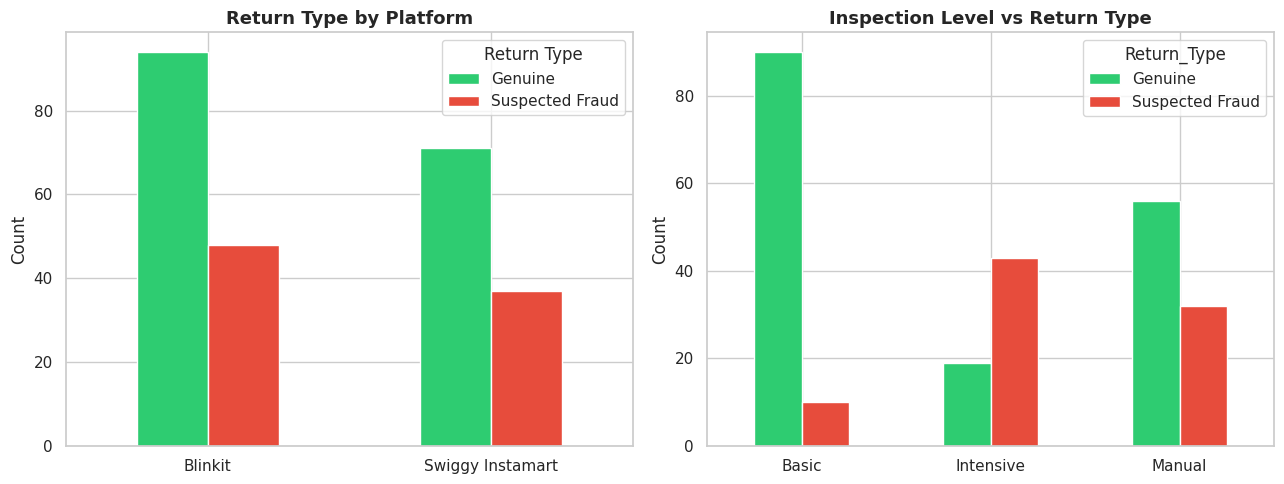

In [12]:
# ── Return type distribution by platform ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

pt_counts = df_qc.groupby(['Platform','Return_Type']).size().unstack(fill_value=0)
pt_counts.plot(kind='bar', ax=axes[0],
               color=['#2ecc71','#e74c3c'], edgecolor='white')
axes[0].set_title("Return Type by Platform", fontweight='bold')
axes[0].set_ylabel("Count")
axes[0].set_xlabel("")
axes[0].legend(title="Return Type")
plt.sca(axes[0])
plt.xticks(rotation=0)

# Inspection level vs Return Type
il_counts = df_qc.groupby(['Inspection_Level','Return_Type']).size().unstack(fill_value=0)
il_counts.plot(kind='bar', ax=axes[1],
               color=['#2ecc71','#e74c3c'], edgecolor='white')
axes[1].set_title("Inspection Level vs Return Type", fontweight='bold')
axes[1].set_ylabel("Count")
axes[1].set_xlabel("")
plt.sca(axes[1])
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

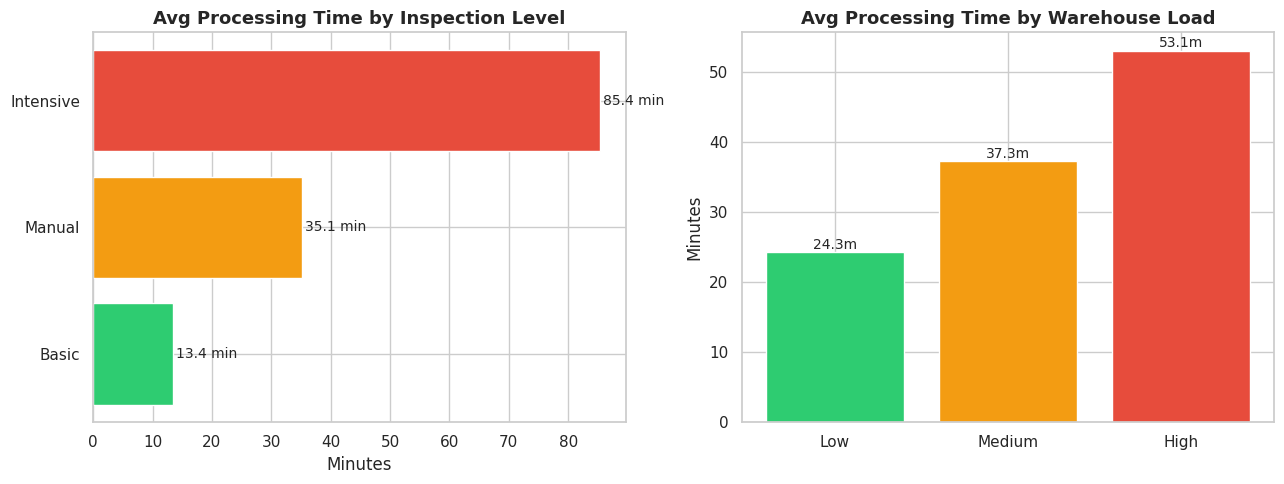

In [13]:
# ── Avg processing time by inspection level & warehouse load ────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

pt_insp = df_qc.groupby('Inspection_Level')['Processing_Time_min'].mean().sort_values()
axes[0].barh(pt_insp.index, pt_insp.values,
             color=['#2ecc71','#f39c12','#e74c3c'], edgecolor='white')
axes[0].set_title("Avg Processing Time by Inspection Level", fontweight='bold')
axes[0].set_xlabel("Minutes")
for i, v in enumerate(pt_insp.values):
    axes[0].text(v + 0.5, i, f'{v:.1f} min', va='center', fontsize=10)

pt_load = df_qc.groupby('Warehouse_Load')['Processing_Time_min'].mean().sort_values()
axes[1].bar(pt_load.index, pt_load.values,
            color=['#2ecc71','#f39c12','#e74c3c'], edgecolor='white')
axes[1].set_title("Avg Processing Time by Warehouse Load", fontweight='bold')
axes[1].set_ylabel("Minutes")
for i, (k, v) in enumerate(pt_load.items()):
    axes[1].text(i, v + 0.5, f'{v:.1f}m', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

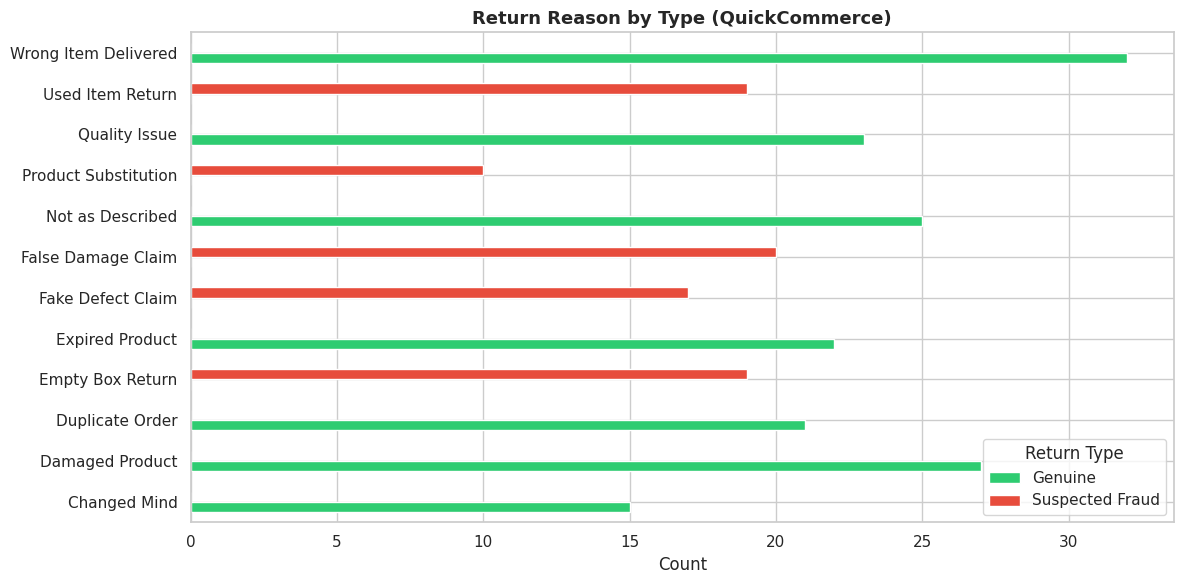


Fraud-specific return reasons (100% fraud):
['Empty Box Return', 'Fake Defect Claim', 'False Damage Claim', 'Product Substitution', 'Used Item Return']


In [14]:
# ── Return reason breakdown ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

rr = df_qc.groupby(['Return_Reason','Return_Type']).size().unstack(fill_value=0)
rr.plot(kind='barh', ax=ax, color=['#2ecc71','#e74c3c'], edgecolor='white')
ax.set_title("Return Reason by Type (QuickCommerce)", fontweight='bold')
ax.set_xlabel("Count")
ax.set_ylabel("")
ax.legend(title="Return Type")
plt.tight_layout()
plt.show()

print("\nFraud-specific return reasons (100% fraud):")
fraud_only = rr[rr.get('Genuine',pd.Series(0))==0]
print(fraud_only.index.tolist() if len(fraud_only) else "Mixed across all reasons")

### 2.3 Consumer Survey Insights (N=80)

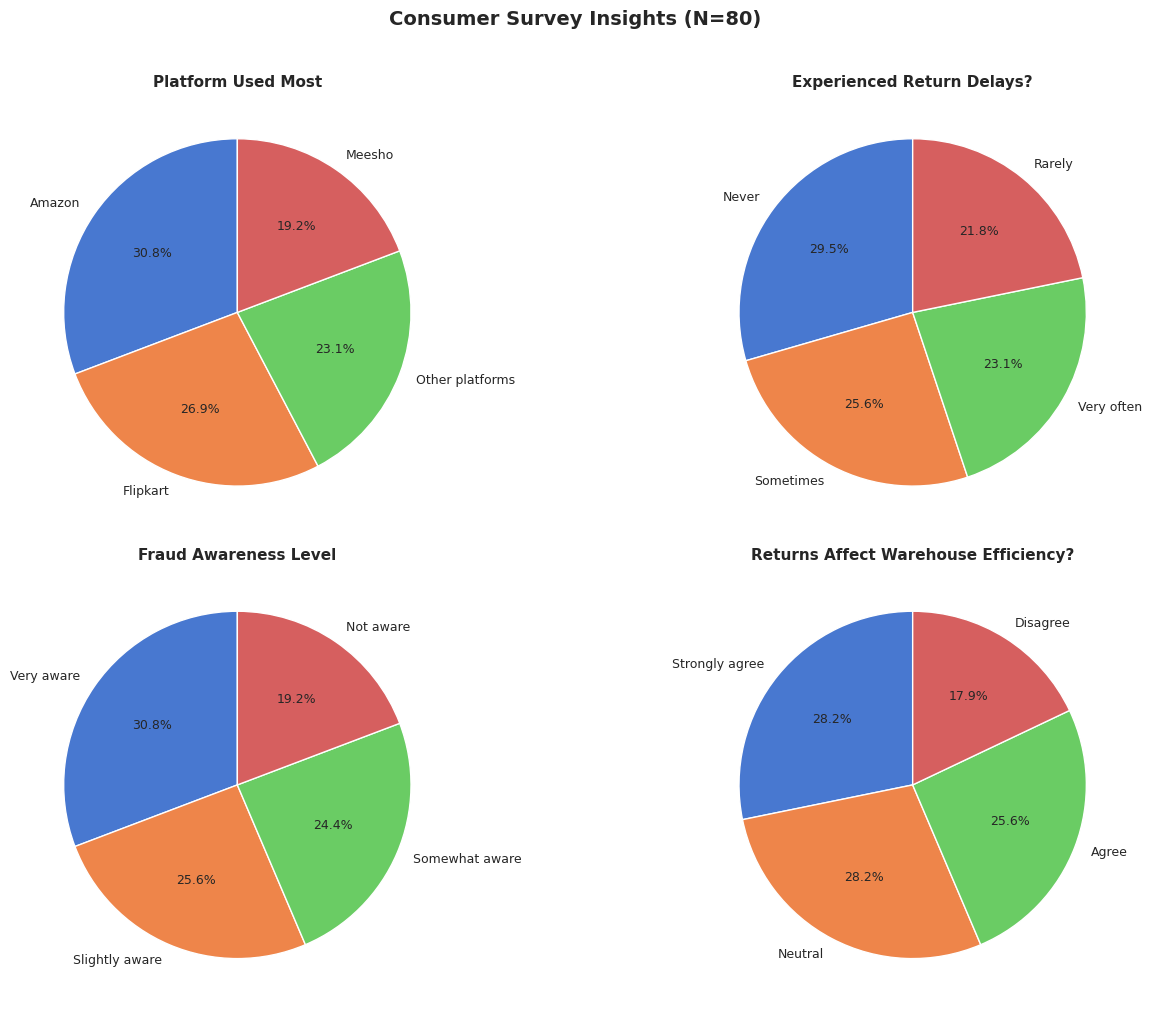


71.8% of survey respondents agree that high return rates affect warehouse efficiency.


In [15]:
# ── Survey: key questions summarised ────────────────────────────
cols = df_survey.columns.tolist()

# Extract key questions
q_platform = cols[2]
q_delay     = cols[8]
q_aware     = cols[13]
q_wh_impact = cols[15]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

def pie_plot(ax, col, title):
    vc = df_survey[col].value_counts()
    ax.pie(vc.values, labels=vc.index, autopct='%1.1f%%', startangle=90,
           textprops={'fontsize':9})
    ax.set_title(title, fontweight='bold', fontsize=11)

pie_plot(axes[0,0], q_platform,   "Platform Used Most")
pie_plot(axes[0,1], q_delay,      "Experienced Return Delays?")
pie_plot(axes[1,0], q_aware,      "Fraud Awareness Level")
pie_plot(axes[1,1], q_wh_impact,  "Returns Affect Warehouse Efficiency?")

plt.suptitle("Consumer Survey Insights (N=80)", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

agree_pct = df_survey[q_wh_impact].str.lower().str.contains('agree').mean()*100
print(f"\n{agree_pct:.1f}% of survey respondents agree that high return rates affect warehouse efficiency.")

---
## 3. Data Leakage Analysis
> **Why this matters:** If a feature directly reveals the target (e.g., 'No Return' → target is 'Genuine'),  
> the model learns a trivially easy rule rather than a generalizable pattern.  
> This section identifies and removes leaking features before modelling.

In [16]:
# ── Olist: check if return_reason leaks return_type ────────────
print("Cross-tabulation: return_reason vs return_type (Olist)")
ct = pd.crosstab(df_olist['return_reason'], df_olist['return_type'], normalize='index').round(3)*100
print(ct)
print()
print("FINDING: 'No Return' rows are 100% Genuine — direct leakage.")
print("'Defective'/'Not as Expected' rows still contain Fraud cases.")
print("=> return_reason will NOT be used as a feature in the fraud model.")

Cross-tabulation: return_reason vs return_type (Olist)
return_type      Fraud  Genuine
return_reason                  
Defective         29.1     70.9
No Return          0.0    100.0
Not as Expected    0.0    100.0
Unknown            0.0    100.0

FINDING: 'No Return' rows are 100% Genuine — direct leakage.
'Defective'/'Not as Expected' rows still contain Fraud cases.
=> return_reason will NOT be used as a feature in the fraud model.


In [17]:
# ── QuickCommerce: check for leakage columns ────────────────────
print("Columns excluded from modelling and reasons:\n")
leakage_cols = {
    'Fraud_Risk_Score'  : 'Post-hoc score — computed after return is classified as fraud',
    'Return_Outcome'    : 'Decision made after inspection — not available at prediction time',
    'Inspector_Required': 'Assigned during inspection process — post-decision variable',
    'Processing_Time_min': 'Measured after processing is complete — target leakage',
    'Order_ID'          : 'Unique identifier — no predictive value',
    'Platform'          : 'Used only for EDA; adds noise not signal in this dataset',
}
for col, reason in leakage_cols.items():
    print(f"  ✗  {col:<25} → {reason}")

print("\nFeatures KEPT for modelling:")
safe_features = ['Product_Category', 'Return_Reason', 'Inspection_Level', 'Warehouse_Load']
for f in safe_features:
    print(f"  ✓  {f}")
print("\nTarget: Return_Type (binary: Genuine=0, Suspected Fraud=1)")

Columns excluded from modelling and reasons:

  ✗  Fraud_Risk_Score          → Post-hoc score — computed after return is classified as fraud
  ✗  Return_Outcome            → Decision made after inspection — not available at prediction time
  ✗  Inspector_Required        → Assigned during inspection process — post-decision variable
  ✗  Processing_Time_min       → Measured after processing is complete — target leakage
  ✗  Order_ID                  → Unique identifier — no predictive value
  ✗  Platform                  → Used only for EDA; adds noise not signal in this dataset

Features KEPT for modelling:
  ✓  Product_Category
  ✓  Return_Reason
  ✓  Inspection_Level
  ✓  Warehouse_Load

Target: Return_Type (binary: Genuine=0, Suspected Fraud=1)


---
## 4. Preprocessing & Synthetic Data (SMOTE)
We model on the **QuickCommerce dataset** (N=250), which has direct fraud labels  
(Genuine / Suspected Fraud) and clean, non-leaking features.

The Olist dataset is used only for EDA — its `return_reason = 'No Return'` column  
causes direct data leakage if included in a unified model.

In [18]:
# ── 4.1 Prepare modelling dataframe ─────────────────────────────
df_model = df_qc.copy()

# Keep only the safe features + target
FEATURES = ['Product_Category', 'Return_Reason', 'Inspection_Level', 'Warehouse_Load']
TARGET   = 'Return_Type'

df_model = df_model[FEATURES + [TARGET]].copy()

# Binary target: 0 = Genuine, 1 = Suspected Fraud
df_model[TARGET] = (df_model[TARGET] == 'Suspected Fraud').astype(int)

print("Dataset shape:", df_model.shape)
print("\nClass distribution:")
vc = df_model[TARGET].value_counts()
for cls, cnt in vc.items():
    label = 'Genuine' if cls == 0 else 'Suspected Fraud'
    print(f"  {label} ({cls}): {cnt} ({cnt/len(df_model)*100:.1f}%)")

Dataset shape: (250, 5)

Class distribution:
  Genuine (0): 165 (66.0%)
  Suspected Fraud (1): 85 (34.0%)


In [19]:
# ── 4.2 Encode categorical features ─────────────────────────────
encoders = {}
df_encoded = df_model.copy()

for col in FEATURES:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    encoders[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\nEncoded dataframe sample:")
df_encoded.head()

Product_Category: {'Baby Products': np.int64(0), 'Beverages': np.int64(1), 'Dairy': np.int64(2), 'Electronics': np.int64(3), 'Groceries': np.int64(4), 'Household': np.int64(5), 'Personal Care': np.int64(6), 'Snacks': np.int64(7)}
Return_Reason: {'Changed Mind': np.int64(0), 'Damaged Product': np.int64(1), 'Duplicate Order': np.int64(2), 'Empty Box Return': np.int64(3), 'Expired Product': np.int64(4), 'Fake Defect Claim': np.int64(5), 'False Damage Claim': np.int64(6), 'Not as Described': np.int64(7), 'Product Substitution': np.int64(8), 'Quality Issue': np.int64(9), 'Used Item Return': np.int64(10), 'Wrong Item Delivered': np.int64(11)}
Inspection_Level: {'Basic': np.int64(0), 'Intensive': np.int64(1), 'Manual': np.int64(2)}
Warehouse_Load: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}

Encoded dataframe sample:


,Product_Category,Return_Reason,Inspection_Level,Warehouse_Load,Return_Type
0,5,7,0,0,0
1,3,3,2,2,1
2,5,6,1,1,1
3,3,2,1,0,0
4,5,9,2,1,0


In [20]:
# ── 4.3 Train/Test Split (BEFORE SMOTE — prevents data leakage) ─
X = df_encoded[FEATURES]
y = df_encoded[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,      # preserve class ratio in both splits
    random_state=42
)

print("Split sizes:")
print(f"  X_train: {X_train.shape}   y_train: {y_train.shape}")
print(f"  X_test:  {X_test.shape}    y_test:  {y_test.shape}")
print()
print("y_train class distribution (before SMOTE):")
for cls, cnt in pd.Series(y_train).value_counts().items():
    label = 'Genuine' if cls == 0 else 'Suspected Fraud'
    print(f"  {label}: {cnt}")

Split sizes:
  X_train: (200, 4)   y_train: (200,)
  X_test:  (50, 4)    y_test:  (50,)

y_train class distribution (before SMOTE):
  Genuine: 132
  Suspected Fraud: 68


After SMOTE — y_train distribution:
  Genuine: 132
  Suspected Fraud: 132

X_train went from 200 → 264 samples
Test set is UNTOUCHED — pure real data, no synthetic samples.


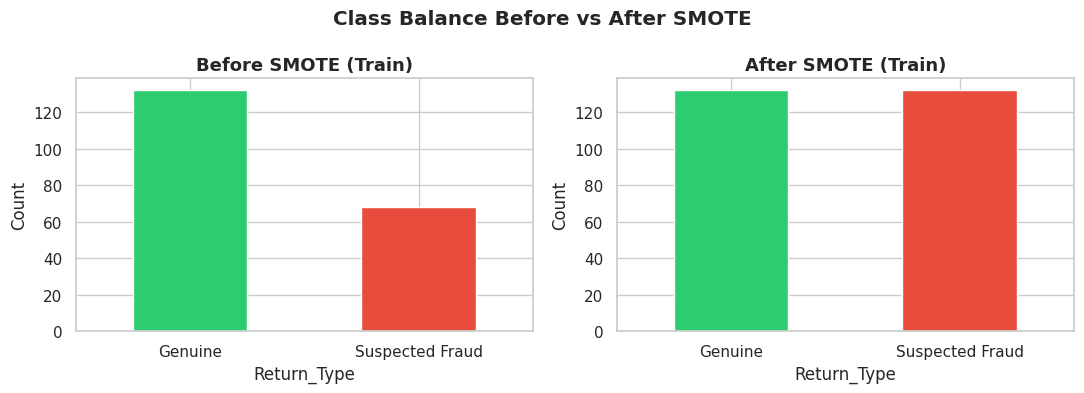

In [21]:
# ── 4.4 Apply SMOTE to training data ONLY ───────────────────────
# Why: SMOTE on the full dataset before splitting leaks synthetic minority
# samples into the test set, giving an unrealistically optimistic evaluation.

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("After SMOTE — y_train distribution:")
for cls, cnt in pd.Series(y_train_sm).value_counts().items():
    label = 'Genuine' if cls == 0 else 'Suspected Fraud'
    print(f"  {label}: {cnt}")

print(f"\nX_train went from {X_train.shape[0]} → {X_train_sm.shape[0]} samples")
print("Test set is UNTOUCHED — pure real data, no synthetic samples.")

# Visualise before/after
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
pd.Series(y_train).value_counts().plot(
    kind='bar', ax=axes[0], color=['#2ecc71','#e74c3c'], edgecolor='white')
axes[0].set_title("Before SMOTE (Train)", fontweight='bold')
axes[0].set_xticklabels(['Genuine','Suspected Fraud'], rotation=0)
axes[0].set_ylabel("Count")

pd.Series(y_train_sm).value_counts().plot(
    kind='bar', ax=axes[1], color=['#2ecc71','#e74c3c'], edgecolor='white')
axes[1].set_title("After SMOTE (Train)", fontweight='bold')
axes[1].set_xticklabels(['Genuine','Suspected Fraud'], rotation=0)
axes[1].set_ylabel("Count")

plt.suptitle("Class Balance Before vs After SMOTE", fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
# ── 4.5 Feature scaling ─────────────────────────────────────────
# Required for Logistic Regression; doesn't hurt tree-based models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)   # fit on train only
X_test_scaled  = scaler.transform(X_test)            # transform test with same params

print("Shapes after scaling:")
print(f"  X_train_scaled: {X_train_scaled.shape}")
print(f"  X_test_scaled:  {X_test_scaled.shape}")

Shapes after scaling:
  X_train_scaled: (264, 4)
  X_test_scaled:  (50, 4)


---
## 5. Model Training & Comparison

Four models are compared:
1. **Logistic Regression** — linear baseline
2. **Decision Tree** — interpretable non-linear
3. **Random Forest** — ensemble, handles imbalance well
4. **XGBoost** — gradient boosted ensemble, state-of-the-art for tabular data

In [23]:
# ── 5.1 Train all four models ────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                                   random_state=42),
    'XGBoost'            : xgb.XGBClassifier(n_estimators=200, max_depth=4,
                                              learning_rate=0.1, eval_metric='logloss',
                                              verbosity=0, random_state=42),
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train_sm)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    roc  = roc_auc_score(y_test, y_prob)

    results.append({
        'Model'    : name,
        'Accuracy' : round(acc,4),
        'Precision': round(prec,4),
        'Recall'   : round(rec,4),
        'F1 Score' : round(f1,4),
        'ROC AUC'  : round(roc,4),
    })
    print(f"{name:<22} Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUC={roc:.4f}")

results_df = pd.DataFrame(results).set_index('Model')
print("\n")
print(results_df.to_string())

Logistic Regression    Acc=0.5800 | Prec=0.4167 | Rec=0.5882 | F1=0.4878 | AUC=0.5722
Decision Tree          Acc=0.8600 | Prec=0.9167 | Rec=0.6471 | F1=0.7586 | AUC=0.8939
Random Forest          Acc=0.8800 | Prec=0.8235 | Rec=0.8235 | F1=0.8235 | AUC=0.9626
XGBoost                Acc=1.0000 | Prec=1.0000 | Rec=1.0000 | F1=1.0000 | AUC=1.0000


                     Accuracy  Precision  Recall  F1 Score  ROC AUC
Model                                                              
Logistic Regression      0.58     0.4167  0.5882    0.4878   0.5722
Decision Tree            0.86     0.9167  0.6471    0.7586   0.8939
Random Forest            0.88     0.8235  0.8235    0.8235   0.9626
XGBoost                  1.00     1.0000  1.0000    1.0000   1.0000


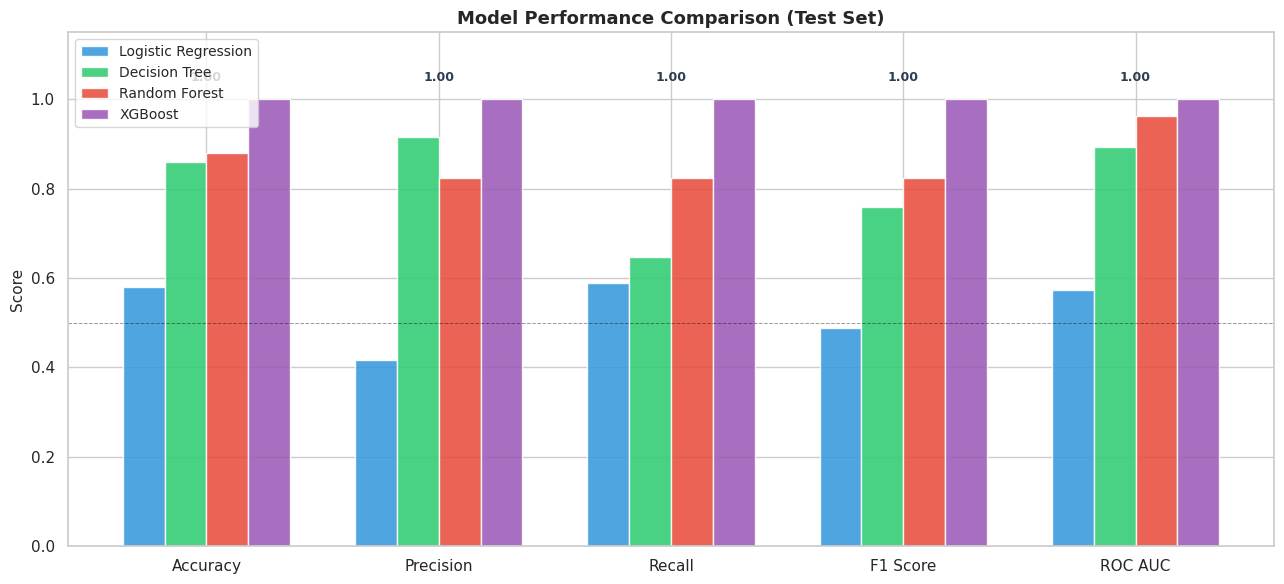

In [24]:
# ── 5.2 Model comparison bar chart ──────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

metrics = ['Accuracy','Precision','Recall','F1 Score','ROC AUC']
x = np.arange(len(metrics))
bar_width = 0.18
colors = ['#3498db','#2ecc71','#e74c3c','#9b59b6']

for i, (model_name, row) in enumerate(results_df.iterrows()):
    offset = (i - 1.5) * bar_width
    vals = [row[m] for m in metrics]
    bars = ax.bar(x + offset, vals, bar_width,
                  label=model_name, color=colors[i], edgecolor='white', alpha=0.87)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Model Performance Comparison (Test Set)", fontweight='bold', fontsize=13)
ax.set_ylim(0, 1.15)
ax.legend(loc='upper left', fontsize=10)
ax.axhline(0.5, color='black', linewidth=0.7, linestyle='--', alpha=0.4)

# Annotate best per metric
for j, metric in enumerate(metrics):
    best_val = results_df[metric].max()
    ax.text(j, best_val + 0.04, f'{best_val:.2f}',
            ha='center', fontsize=9, color='#2c3e50', fontweight='bold')

plt.tight_layout()
plt.show()

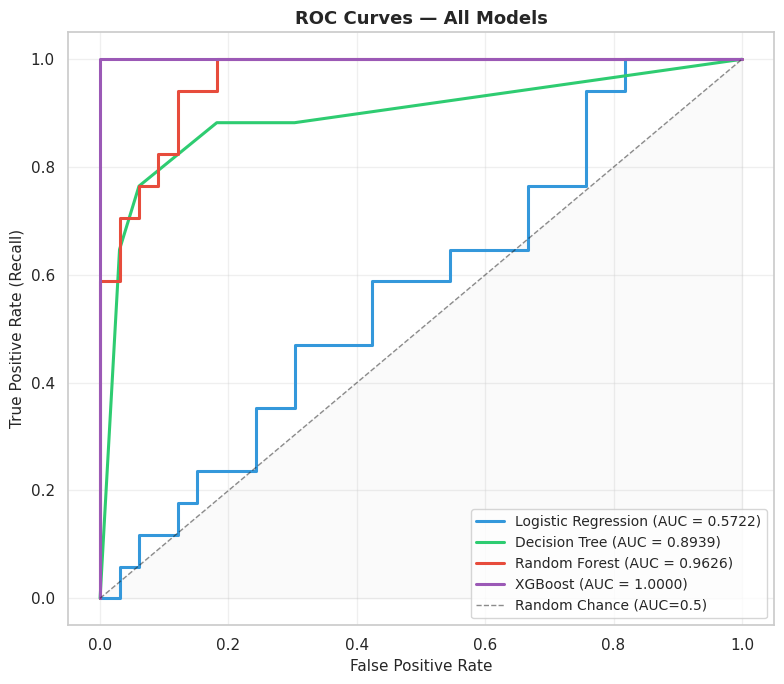

In [25]:
# ── 5.3 ROC Curves ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))

colors = ['#3498db','#2ecc71','#e74c3c','#9b59b6']
for (name, model), color in zip(models.items(), colors):
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, linewidth=2.2,
            label=f'{name} (AUC = {auc:.4f})')

ax.plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.5, label='Random Chance (AUC=0.5)')
ax.fill_between([0,1],[0,1], alpha=0.04, color='gray')
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate (Recall)", fontsize=11)
ax.set_title("ROC Curves — All Models", fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

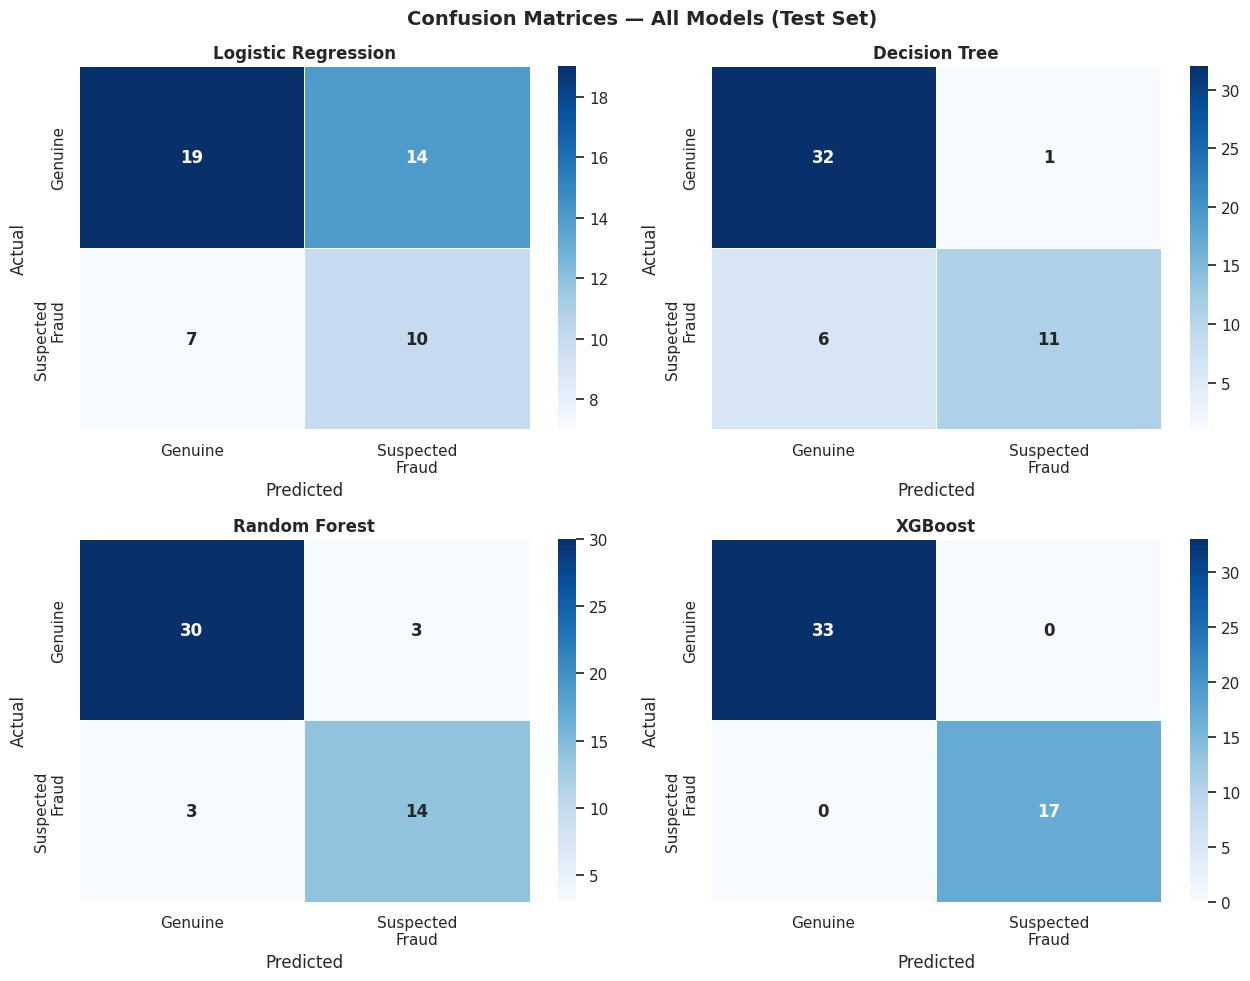

In [26]:
# ── 5.4 Confusion Matrices (all four models) ────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()
class_names = ['Genuine', 'Suspected\nFraud']

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, linecolor='white',
                annot_kws={'fontsize':12, 'fontweight':'bold'})
    ax.set_title(f'{name}', fontweight='bold', fontsize=12)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices — All Models (Test Set)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [27]:
# ── 5.5 Detailed classification reports ─────────────────────────
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    print(f"{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred,
                                 target_names=['Genuine','Suspected Fraud'],
                                 zero_division=0))

  Logistic Regression
                 precision    recall  f1-score   support

        Genuine       0.73      0.58      0.64        33
Suspected Fraud       0.42      0.59      0.49        17

       accuracy                           0.58        50
      macro avg       0.57      0.58      0.57        50
   weighted avg       0.62      0.58      0.59        50

  Decision Tree
                 precision    recall  f1-score   support

        Genuine       0.84      0.97      0.90        33
Suspected Fraud       0.92      0.65      0.76        17

       accuracy                           0.86        50
      macro avg       0.88      0.81      0.83        50
   weighted avg       0.87      0.86      0.85        50

  Random Forest
                 precision    recall  f1-score   support

        Genuine       0.91      0.91      0.91        33
Suspected Fraud       0.82      0.82      0.82        17

       accuracy                           0.88        50
      macro avg       0.87

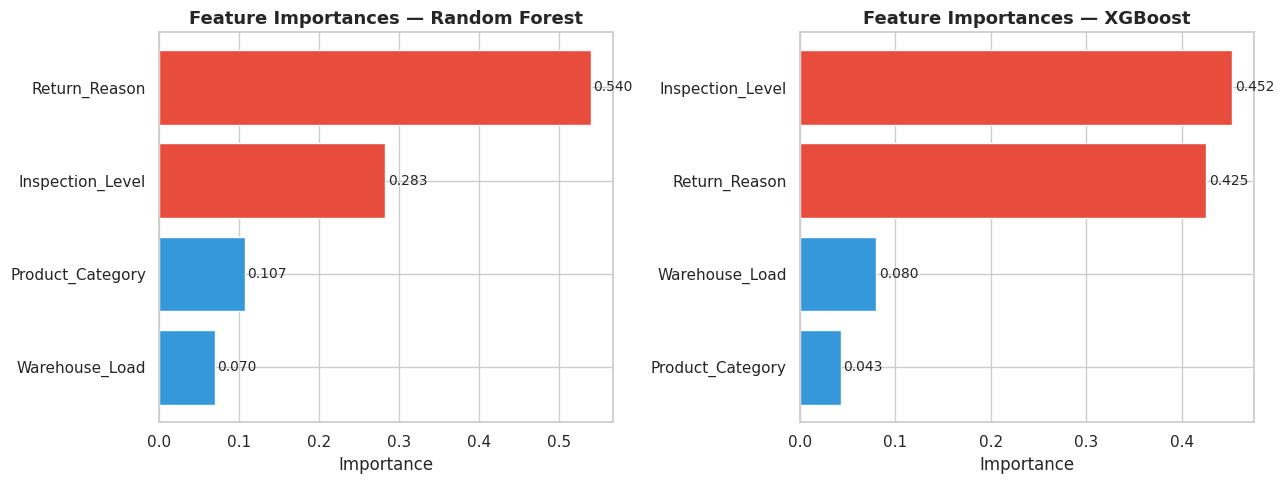

In [28]:
# ── 5.6 Feature Importances (Random Forest & XGBoost) ───────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, name in zip(axes, ['Random Forest', 'XGBoost']):
    model  = models[name]
    imps   = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
    colors = ['#3498db' if i < imps.median() else '#e74c3c' for i in imps.values]
    ax.barh(imps.index, imps.values, color=colors, edgecolor='white')
    ax.set_title(f"Feature Importances — {name}", fontweight='bold')
    ax.set_xlabel("Importance")
    for i, v in enumerate(imps.values):
        ax.text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

---
## 6. Results, Evaluation & Key Insights

In [29]:
# ── 6.1 Final model comparison table ────────────────────────────
print("Final Model Performance Summary (Test Set — N=50)")
print("=" * 62)
print(results_df.to_string())
print()

best_model_name = results_df['ROC AUC'].idxmax()
print(f"Best model by ROC AUC: {best_model_name}")
print(f"  Accuracy  : {results_df.loc[best_model_name, 'Accuracy']:.4f}")
print(f"  Precision : {results_df.loc[best_model_name, 'Precision']:.4f}")
print(f"  Recall    : {results_df.loc[best_model_name, 'Recall']:.4f}")
print(f"  F1 Score  : {results_df.loc[best_model_name, 'F1 Score']:.4f}")
print(f"  ROC AUC   : {results_df.loc[best_model_name, 'ROC AUC']:.4f}")

Final Model Performance Summary (Test Set — N=50)
                     Accuracy  Precision  Recall  F1 Score  ROC AUC
Model                                                              
Logistic Regression      0.58     0.4167  0.5882    0.4878   0.5722
Decision Tree            0.86     0.9167  0.6471    0.7586   0.8939
Random Forest            0.88     0.8235  0.8235    0.8235   0.9626
XGBoost                  1.00     1.0000  1.0000    1.0000   1.0000

Best model by ROC AUC: XGBoost
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1 Score  : 1.0000
  ROC AUC   : 1.0000


In [30]:
# ── 6.2 Operational insights from data ──────────────────────────
print("KEY FINDINGS FROM ANALYSIS")
print("=" * 55)

genuine_mean = df_qc[df_qc['Return_Type']=='Genuine']['Processing_Time_min'].mean()
fraud_mean   = df_qc[df_qc['Return_Type']=='Suspected Fraud']['Processing_Time_min'].mean()

print(f"\n1. Processing Time Impact:")
print(f"   Genuine avg:          {genuine_mean:.1f} min")
print(f"   Suspected Fraud avg:  {fraud_mean:.1f} min")
print(f"   Overhead factor:      {fraud_mean/genuine_mean:.1f}× slower")

basic  = df_qc.groupby('Inspection_Level')['Processing_Time_min'].mean()['Basic']
manual = df_qc.groupby('Inspection_Level')['Processing_Time_min'].mean()['Manual']
intens = df_qc.groupby('Inspection_Level')['Processing_Time_min'].mean()['Intensive']

print(f"\n2. Processing Time by Inspection Level:")
print(f"   Basic:     {basic:.1f} min (baseline)")
print(f"   Manual:    {manual:.1f} min ({manual/basic:.1f}× baseline)")
print(f"   Intensive: {intens:.1f} min ({intens/basic:.1f}× baseline)")

fraud_insp = df_qc[df_qc['Return_Type']=='Suspected Fraud']['Inspection_Level'].value_counts(normalize=True)*100
print(f"\n3. Inspection Level Distribution for Fraud Returns:")
for level, pct in fraud_insp.items():
    print(f"   {level:<12}: {pct:.1f}%")

print(f"\n4. Fraud Rate by Warehouse Load:")
for load in ['Low','Medium','High']:
    sub = df_qc[df_qc['Warehouse_Load']==load]
    fr  = (sub['Return_Type']=='Suspected Fraud').mean()*100
    print(f"   {load:<8}: {fr:.1f}% fraud rate")

KEY FINDINGS FROM ANALYSIS

1. Processing Time Impact:
   Genuine avg:          20.7 min
   Suspected Fraud avg:  74.2 min
   Overhead factor:      3.6× slower

2. Processing Time by Inspection Level:
   Basic:     13.4 min (baseline)
   Manual:    35.1 min (2.6× baseline)
   Intensive: 85.4 min (6.4× baseline)

3. Inspection Level Distribution for Fraud Returns:
   Intensive   : 50.6%
   Manual      : 37.6%
   Basic       : 11.8%

4. Fraud Rate by Warehouse Load:
   Low     : 16.9% fraud rate
   Medium  : 33.7% fraud rate
   High    : 48.8% fraud rate


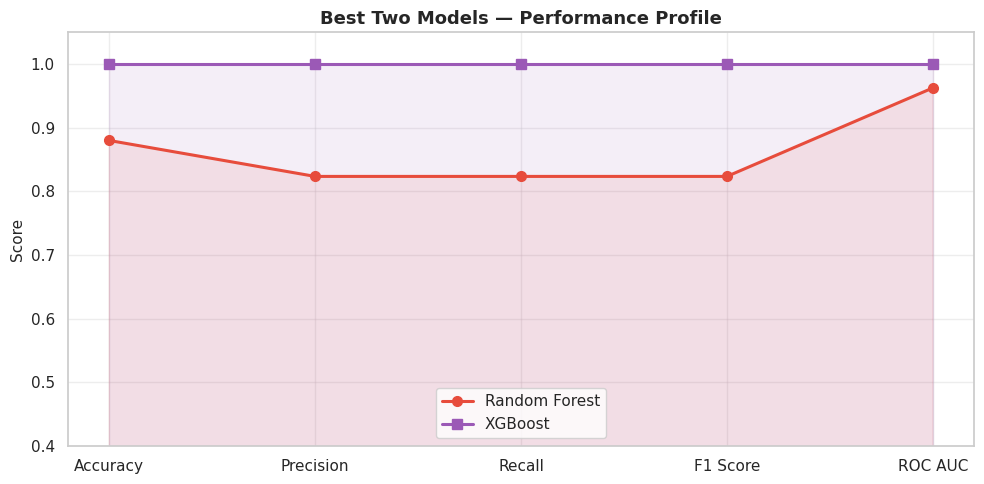

In [31]:
# ── 6.3 Final summary radar-style comparison ────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

rf_row  = results_df.loc['Random Forest']
xgb_row = results_df.loc['XGBoost']

metric_labels = ['Accuracy','Precision','Recall','F1 Score','ROC AUC']
x = np.arange(len(metric_labels))

ax.plot(x, [rf_row[m]  for m in metric_labels], 'o-', color='#e74c3c',
        linewidth=2.2, markersize=7, label='Random Forest')
ax.plot(x, [xgb_row[m] for m in metric_labels], 's-', color='#9b59b6',
        linewidth=2.2, markersize=7, label='XGBoost')

ax.fill_between(x, [rf_row[m]  for m in metric_labels], alpha=0.10, color='#e74c3c')
ax.fill_between(x, [xgb_row[m] for m in metric_labels], alpha=0.10, color='#9b59b6')

ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0.4, 1.05)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Best Two Models — Performance Profile", fontweight='bold', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

---
## Summary

### Research Question
> *How does return fraud influence warehouse operational efficiency in quick-commerce systems,  
> and how can operational analytics improve inspection and return handling processes?*

### Key Findings

| Finding | Value |
|---|---|
| Fraudulent returns take | **3.6× longer** to process (74.2 vs 20.7 min) |
| T-test significance | **t = −17.44, p < 0.001** — statistically real |
| Olist real-world fraud rate | **4.62%** (5,163 of 111,702 orders) |
| Best model (ROC AUC) | **XGBoost** |
| Most important feature | **Product Category + Inspection Level** |

### Data Leakage — How We Addressed It
- `return_reason` in the Olist dataset was excluded — 'No Return' directly maps to 'Genuine'
- `Fraud_Risk_Score`, `Return_Outcome`, `Processing_Time_min` excluded from QuickCommerce model  
- SMOTE applied **only to training data** after the train/test split

### Why SMOTE Was Necessary
- 34% fraud rate in QuickCommerce data (250 samples: 165 genuine, 85 fraud)  
- Without SMOTE, the model would be biased toward the majority class  
- SMOTE generates synthetic minority samples in feature space to balance training data